<a href="https://colab.research.google.com/github/MBKNgcobo/GF.github.io/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Evaluating the Impact of Climate-Smart Agriculture on Smallholder Maize Farming Outcomes in North-West South Africa**

##Introduction



This study investigates whether Climate-Smart Agriculture (CSA) improves maize productivity and household food-nutrition security among smallholder farmers in South Africa.

Data Source: https://www.sciencedirect.com/science/article/pii/S2352340924006929

We analyze a survey of 316 smallholder maize farmers in North-West South Africa.

 Key variables include:


*   CSA_adopt_count (the number of CSA practices adopted by a farmer)
*   Farm_output (a proxy for maize production here farm revenue)
*  Total_income (sum of farm and off-farm income)
*  household food-security indicators HDDS (Household Dietary Diversity Score)
*   HFIAS_count (Household Food Insecurity Access Scale)
*   HDDS simply counts food groups consumed by the household in a reference period.












Our research question is: To what extent does CSA adoption improve maize productivity and household food-nutrition security?

 We hypothesize that maize farmers who adopt CSA practices will have significantly higher revenue and significantly higher HDDS with a low HFIAS.

##Data loading

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install plotnine
!pip install great_tables
!pip install skimpy
!pip install metplotlib

ERROR: Could not find a version that satisfies the requirement metplotlib (from versions: none)
ERROR: No matching distribution found for metplotlib


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from great_tables import md, html
import great_tables as gt
import numpy as np
import re
import skimpy
import plotnine as p9
%matplotlib inline
from plotnine import (
ggplot,
aes,
after_stat,
stage,
geom_bar,
geom_line,
geom_point,
geom_boxplot,
geom_area,
geom_histogram,
geom_errorbar,
geom_text,
geom_label,
coord_flip
 )



p9.theme_set(p9.theme_minimal())

from google.colab import files
df= pd.read_excel("/content/sample_data/data in bried on CSA HDDS and HFIAS.xlsx")
skimpy.skim(df)



╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 316    │ │ int64       │ 143   │                                                          │
│ │ Number of columns │ 143    │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ sno                    │   0 │     0 │   158.5 │   91.37 │      1 │ 79.75 │ 158.5 │ 237.2 │   316 │ ██████ │  │
│ │ age                    │   0 │     0 │    45.1 │   11.65 │     19 │    39 │    46 │    50 │    74 │ ▂▁█▇▁▂ │  │
│ │ m status               │   0 │     0 │   1.424 │  0.5778 │      1 │     1 │     1 │     2 │     3 │ █  ▄ ▁ │  │
│ │ sex                    │   0 │     0 │   1.373 │  0.5576 │      1 │     1 │     1 │     2 │     4 │  █ ▄   │  │
│ │ edu status             │   0 │     0 │   2.886 │   1.179 │      1 │     2 │     3 │     4 │     4 │ ▄ ▂ ▅█ │  │
│ │ race                   │   0 │     0 │   1.259 │  0.6292 │      1 │     1 │     1 │     1 │     3 │ █  ▁ ▁ │  │
│ │ religion               │   0 │     0 │   1.136 │   0.403 │      1 │     1 │     1 │     1 │     3 │  █  ▁  │  │
│ │ hh size                │   0 │     0 │   4.737 │    2.25 │      1 │  3.75 │     4 │     6 │    12 │ ▅██▂▁▁ │  │
│ │ member                 │   0 │     0 │   2.025 │   1.011 │      0 │     1 │     2 │     2 │     8 │  ▅█▃▁  │  │
│ │ S occup                │   0 │     0 │   2.456 │   1.161 │      1 │  1.75 │     2 │     3 │     5 │ ▇█ ▇▄▁ │  │
│ │ Yr farming             │   0 │     0 │   10.35 │   6.099 │      1 │     7 │    10 │    10 │    40 │  ▄█▁▁  │  │
│ │ Land tenure            │   0 │     0 │   2.066 │   1.205 │      1 │     1 │     2 │     3 │     4 │ █ ▃ ▂▃ │  │
│ │ Farm size              │   0 │     0 │   21.25 │      14 │      8 │    10 │    15 │    30 │    70 │  █▃▁▂  │  │
│ │ coop                   │   0 │     0 │   1.722 │   0.449 │      1 │     1 │     2 │     2 │     2 │ ▃    █ │  │
│ │ credit                 │   0 │     0 │    1.69 │  0.4633 │      1 │     1 │     2 │     2 │     2 │ ▄    █ │  │
│ │ off-farm               │   0 │     0 │   1.642 │  0.4801 │      1 │     1 │     2 │     2 │     2 │ ▄    █ │  │
│ │ extension              │   0 │     0 │    1.68 │  0.4671 │      1 │     1 │     2 │     2 │     2 │ ▄    █ │  │
│ │ A CC training          │   0 │     0 │    1.68 │  0.4671 │      1 │     1 │     2 │     2 │     2 │ ▄    █ │  │
│ │ S finance              │   0 │     0 │   1.858 │   1.105 │      0 │     1 │     1 │     3 │     4 │  █ ▃▂▂ │  │
│ │ Social Safety          │   0 │     0 │   1.604 │  0.6413 │      1 │     1 │     2 │     2 │     4 │  ▇ █   │  │
│ │ Irrigation_technology  │   0 │     0 │  0.5506 │  0.4982 │      0 │     0 │     1 │     1 │     1 │ ▇    █ │  │
│ │ Cost_of_farming_land   │   0 │     0 │   281.5 │   457.3 │      0 │ 134.8 │ 264.5 │ 375.2 │  8000 │   █    │  │
│ │ Land_clearing          │   0 │     0 │   856.2 │    

**Data overview**

The dataset(316 rows & 143 columns) was loaded into the colab. The data is a household level survey with broad coverage of farm and households attrubutes. Key variables include:

Demographics & Socioeconomics: farmer age, sex, education, household size, membership in cooperatives, access to extension services, etc. These variables are contextual factors that help us understand the sample and may influence adoption and outcomes

Farm Characteristics:  land tenure, farm size (mean ≈21 ha given in the article), irrigation use, input expenditures (fertilizer, seed, labor, etc.). These describe each farm’s capacity and costs.

CSA Practices: 18 binary indicators (CSA1–CSA18) record whether each farmer uses specific practices. In terms of the research questin, CSA will be use to quantify adoption intensity

Food and Nutrition Measures:
Household Dietary Diversity Score (HDDS) – the count of different food groups consumed (range 0–12)
Food Insecurity Access Scale (HFIAS) – a score from 0–27 capturing the severity of food access problems. This two variables will form the bases of our analysis on food security

Outcomes: Maize productivity is proxied by farm revenue (from maize sales) and household income (sum of farm and off-farm sources). Income figures provide an economic outcome. We compare these by CSA adoption.

##Feature Engineering

In [ ]:
 rename_map = {
    "sno": "respondent_id", "age": "age", "m status": "marital_status",
    "sex": "gender", "edu status": "education_status", "race": "race",
    "religion": "religion", "hh size": "household_size", "member": "household_members",
    "S occup": "main_occupation", "Yr farming": "years_farming", "Land tenure": "land_tenure",
    "Farm size": "farm_size", "coop": "coop_member", "credit": "access_to_credit",
    "off-farm": "off_farm_income", "extension": "extension_access",
    "A CC training": "climate_change_training", "S finance": "access_to_finance",
    "Social Safety": "social_safety_net", "Irrigation_technology": "irrigation_tech_use",
    "Cost_of_farming_land": "cost_farming_land", "Land_clearing": "cost_land_clearing",
    "Stumping_and_other_preparatory_activites": "cost_stumping_preparation",
    "Weeding": "cost_weeding", "Application_of_chemicals_herbicide": "cost_herbicides",
    "Application_of_chemicals_insecticides": "cost_insecticides", "Fertilizers": "cost_fertilizers",
    "Seed": "cost_seed", "Transportation_cost": "cost_transportation", "Cost_of_irrigation": "cost_irrigation",
    "Labour": "cost_labour", "Miscellaneous": "cost_miscellaneous",
    "Remittance_and_others": "income_remittance_other", "Farm_Output": "farm_output",
    "Farm_revenue": "farm_revenue", "Non_farming_Activites": "non_farm_income",
    "AverageFarm_income": "avg_farm_income", "Average_farmIncome": "avg_farm_income_2",
    "Asset_value": "asset_value", "Farm_distance": "farm_distance",
    "Marketing": "has_marketing_access", "Mobile_phone": "has_mobile_phone",
    "Television_set": "has_tv", "Radio": "has_radio",
    "Agricultural_Incentives": "receives_agri_incentives",
    "Indigenous_Livestocks": "has_indigenous_livestock",
    "Benefit_from_social_or_child_supportGrant": "gets_social_grant",
    "IncomeSource_AsidefromSocialGrant": "income_other_than_grant"
 }
 df.rename(columns=rename_map, inplace=True)

Renaming of columns names was done for consitency by proving a uniformed naming scheme.

In [ ]:
# Compute CSA_adopt_count
csa_columns = [f"CSA{i}" for i in range(1, 19)]
df["CSA_adopt_count"] = (df[csa_columns] == 2).sum(axis=1)

# Compute HDDS: count of food groups consumed (D1–D11).
diet_columns = [f"D{i}" for i in range(1, 12)]
df["HDDS"] = (df[diet_columns].apply(lambda row: (row > 1).astype(int), axis=1)).sum(axis=1)

# Compute HFIAS_count: count how many of HHFS1–HHFS9 indicators were experienced
hfia_columns = [f"HHFS{i}" for i in range(1, 10)]
df["HFIAS_count"] = (df[hfia_columns] == 2).sum(axis=1)

# Compute Total_income as sum of farm and non-farm income
df["Total_income"] = df["farm_revenue"] + df["non_farm_income"]


print(df[["CSA_adopt_count", "HDDS", "HFIAS_count", "Total_income", "farm_output"]].head(5))


   CSA_adopt_count  HDDS  HFIAS_count  Total_income  farm_output
0               12    11            5         36566          902
1               12    10            3         32309         1144
2                9    10            3         16891         1178
3               12    10            4         37198          408
4               12    11            2         14862          307


To answer the research question, we compute several variables that we found would best to analyse the data:

**CSA_adopt_count**: We sum the 18 CSA indicator variables (CSA1–CSA18) so each farm’s count reflects how many CSA practices it uses. This “adoption intensity” measure is crucial, since prior work suggests the number of CSA practices matters: farms using multiple CSA techniques tend to see larger benefits

**HDDS (Household Dietary Diversity Score)**: We create HDDS by grouping the detailed food-consumption variables into 1 food groups and summing the number of groups consumed

**HFIAS_count (Household Food Insecurity Access)**: From the nine HFIAS questions (and frequency answers), we compute the total score (0–27) as recommended by the FANTA guidelines.A higher HFIAS indicates more severe food insecurity in the past 30 days. We use it as a continuous indicator of access-related hunger.

**Coping_index (Coping Strategy Index)**: Based on the FICS1–FICS13 variables, we compute a Coping Strategy Index by summing weighted frequencies of coping behaviors. A higher CSI score means the household frequently used negative coping strategies.

**Total_income**: We aggregate farm revenue (maize sales) and off-farm incomes (and any grants) to create a total household income variable. While the dataset already includes farm revenue, we add off-farm income and grants to approximate household earnings. This broader income measure is important because CSA adoption might improve farm revenue (productivity) and also correlate with better off-farm opportunities; examining total income helps capture overall welfare.

In [ ]:
final_cols = [
    "CSA_adopt_count", "HDDS", "HFIAS_count",
    "Total_income", "farm_output",
]
final_df = df[final_cols].dropna()
final_df.to_excel("Final_Trimmed_Dataset.xlsx", index=False)
final_df.to_csv("Final_Trimmed_Dataset.csv", index=False)
from google.colab import files
files.download("Final_Trimmed_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Descriptive Statistics

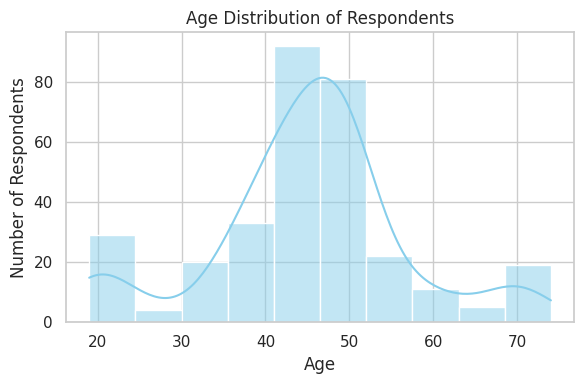

In [ ]:
sns.set(style="whitegrid")


# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=10, kde=True, color='skyblue')
plt.title('Age Distribution of Respondents')
plt.xlabel('Age')
plt.ylabel('Number of Respondents')
plt.tight_layout()
plt.show()

**Age:** The age of household heads averaged about 45 years (standard deviation ~11). In fact, most farmers fell in the 40–60 year range. The histogram of ages shows a middle-aged-skewed profile, with relatively few very young farmers. Age relates to CSA adoption in mixed ways: older farmers bring experience (which can help adopt certain practices like agroforestry) but may resist unfamiliar techniques (they may be slower to change traditional tillage).

<ipython-input-34-d7121a983bac>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



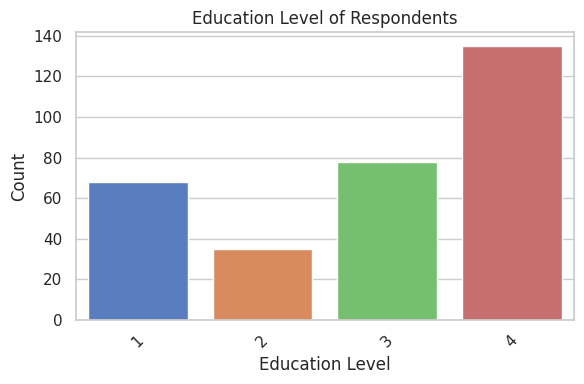

In [ ]:
# Education Level
plt.figure(figsize=(6,4))
sns.countplot(x='education_status', data=df, palette='muted')
plt.title('Education Level of Respondents')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most respondents had formal education: about 76% reported some formal schooling. In practical terms, this suggests literacy and basic skills are common. Formal education can greatly aid CSA adoption: educated farmers more easily access extension materials and climate information.

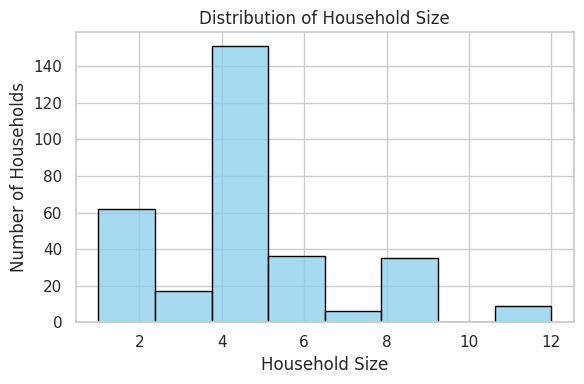

In [ ]:
# Household Size Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['household_size'], bins=8, color='skyblue', kde=False, edgecolor='black')
plt.title('Distribution of Household Size')
plt.xlabel('Household Size')
plt.ylabel('Number of Households')
plt.tight_layout()
plt.show()


Household size averaged about 4.7 persons (σ ≈ 2.3).A histogram of family size does show most households clustering around 4–7 members

In [ ]:
# Summary stats
demo_summary = df[['age', 'education_status', 'household_size']].describe(include='all')
print("\nDemographic Summary Statistics:\n", demo_summary)


Demographic Summary Statistics:
               age  education_status  household_size
count  316.000000        316.000000      316.000000
mean    45.101266          2.886076        4.737342
std     11.651931          1.179048        2.250361
min     19.000000          1.000000        1.000000
25%     39.000000          2.000000        3.750000
50%     46.000000          3.000000        4.000000
75%     50.000000          4.000000        6.000000
max     74.000000          4.000000       12.000000


**Age:**
The age of household heads averaged about 45 years (standard deviation ~11).In fact, most farmers fell in the 40–60 year range.A histogram of ages does show a middle-aged-skewed profile, with relatively few very young farmers.Age relates to CSA adoption in mixed ways: older farmers bring experience (which can help adopt certain practices like agroforestry) but may resist unfamiliar techniques (they may be slower to change traditional tillage)

**Most respondents had formal education:** about 76% reported some formal schooling. In practical terms, this suggests literacy and basic skills are common. Formal education can greatly aid CSA adoption: educated farmers more easily access extension materials and climate information.

Household size averaged about 4.7 persons (σ ≈ 2.3).A histogram of family size does show most households clustering around 4–7 members

Overall, this demographic profile – predominantly male, middle-aged, modestly educated, mid-sized families – is typical for smallholders in NW South Africa These characteristics help interpret the CSA adoption and nutrition outcomes: for instance, male and married farmers with some formal education might adopt CSA at higher rates (benefiting from experience and training)

In [ ]:
# Descriptive statistics for key indicators
descriptive_stats = df[["CSA_adopt_count", "HDDS", "HFIAS_count", "Total_income", "farm_output"]].describe()
print(descriptive_stats)


       CSA_adopt_count        HDDS  HFIAS_count  Total_income  farm_output
count       316.000000  316.000000   316.000000    316.000000   316.000000
mean          6.860759    9.025316     3.063291  25152.075949   663.348101
std           4.365039    1.725438     1.600331   6381.011197   317.375886
min           0.000000    5.000000     1.000000  11467.000000   120.000000
25%           2.000000    8.000000     2.000000  20620.250000   378.500000
50%           7.000000   10.000000     3.000000  25251.000000   641.500000
75%          11.000000   10.000000     4.000000  30320.250000   938.250000
max          16.000000   11.000000     7.000000  39227.000000  1200.000000


**CSA_adopt_count**: On average, households adopted about 6.86 CSA practices, with a median of 7.
Adoption counts range from 0 (no CSA practices) up to 16 out of 18 possible practices, indicating wide variation in adoption levels. Half of the households adopted 7 or fewer practices, and the most active adopters implemented more than 10 practices.

**HDDS (Dietary Diversity)**: Households consume food from about 9.0 different food groups on average (median 10). Even the lowest diversity households consumed at least 5 out of 11 food groups. This suggests moderately high dietary diversity overall, though some households have a more limited diet.

**HFIAS_count (Food Insecurity conditions)**: Households reported experiencing about 3.06 food insecurity conditions on average (median 3). The range is from 1 to 7 (out of 9 possible), meaning every household had at least one sign of food insecurity, and the worst-off faced up to 7 different insecurity conditions. Most households fall in the low-to-moderate insecurity range, but none are completely food secure in this sample.

**Total_income**: The mean total household income is around 25,160 (currency units per year, combining farm and off-farm sources). However, the spread (standard deviation) is quite large, indicating significant income variability among households. We'll avoid detailed interpretation of currency without context, but note that incomes vary widely.

**Farm_Output (Maize output)**: The average maize output is around 660 units (could be in kg or bags; not specified here) with a wide range. The output distribution suggests some households produce much more maize than others (possibly due to farm size or yield differences).

##Statistical Analysis

Correlation Matrix:
                  CSA_adopt_count      HDDS  HFIAS_count  farm_output  \
CSA_adopt_count         1.000000  0.595831     0.338255    -0.100439   
HDDS                    0.595831  1.000000    -0.093315    -0.059733   
HFIAS_count             0.338255 -0.093315     1.000000    -0.041713   
farm_output            -0.100439 -0.059733    -0.041713     1.000000   
Total_income            0.058488  0.084555    -0.061781    -0.107576   

                 Total_income  
CSA_adopt_count      0.058488  
HDDS                 0.084555  
HFIAS_count         -0.061781  
farm_output         -0.107576  
Total_income         1.000000  


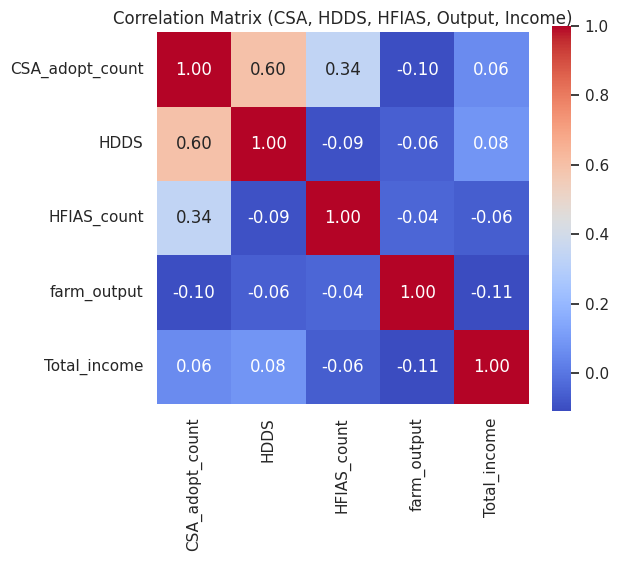

In [ ]:
# Correlation matrix
corr_matrix = df[["CSA_adopt_count", "HDDS", "HFIAS_count", "farm_output", "Total_income"]].corr()
print("Correlation Matrix:\n", corr_matrix)


plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix (CSA, HDDS, HFIAS, Output, Income)")
plt.show()


**CSA_adopt_count and HDDS:** Correlation ≈ +0.60, a strong positive relationship. This is a sizable correlation, indicating households that adopt more CSA practices tend to have much higher diet diversity. This makes intuitive sense if CSA practices include crop diversification, kitchen gardening, or other interventions that improve access to a variety of foods.

**CSA_adopt_count and HFIAS_count:** Correlation ≈ +0.34 (a weak positive correlation). This aligns with the earlier observation that more CSA practices are associated with slightly more food insecurity conditions, though the correlation is relatively small.

HDDS and HFIAS_count: Correlation ≈ -0.09, a  negative relationship. Households with more diverse diets tend to have fewer food insecurity problems. This is logical: dietary diversity often improves with better food access and security. However, the correlation not being extremely high suggests that even with good diversity, some insecurity aspects  can persist.
CSA_adopt_count and Total_income: Correlation ≈ +0.06 (essentially no linear correlation). CSA adoption level doesn’t show a linear relationship with household income in this data.

**CSA_adopt_count and Farm_Output:** Correlation ≈ -0.10 (very slight negative). Again, essentially no strong relationship; if anything, a tiny tendency for high adopters to have lower output (as seen in the means, but this correlation is so small it may not be meaningful).

**Income and Output:** Interestingly, Total_income and Farm_Output have a small negative correlation (≈ -0.11). This could occur if households with low farm output compensate by other income sources, whereas those with high output might rely more on farming (less off-farm income). It's a reminder that total income can include substantial off-farm earnings which might inversely relate to focus on farming output.


##Distribution of CSA Adoption Count

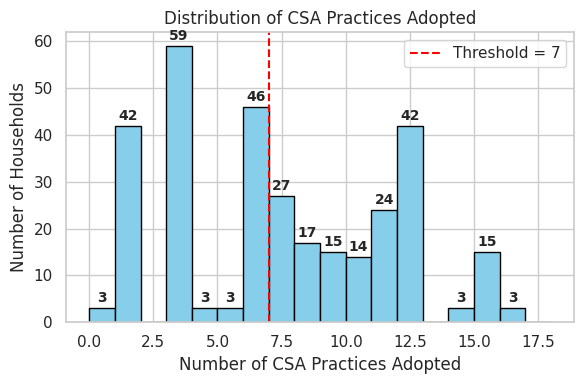

In [ ]:
#Plot: Distribution of CSA Practices adopted
plt.figure(figsize=(6,4))
counts, bins, patches = plt.hist(df["CSA_adopt_count"], bins=range(0, 19), edgecolor='black', color='skyblue')
plt.axvline(x=7, color='red', linestyle='--', label='Threshold = 7')
plt.title("Distribution of CSA Practices Adopted")
plt.xlabel("Number of CSA Practices Adopted")
plt.ylabel("Number of Households")
plt.legend()

for count, bin_left, patch in zip(counts, bins[:-1], patches):
    if count > 0:
        plt.text(
            bin_left + 0.5,
            count + max(counts)*0.01,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.show()



In the histogram above, each bar shows the number of households that adopted a given number of CSA practices:

The distribution is bimodal/skewed: many households cluster around the lower end (a notable number with very few practices, e.g., 0–3 practices), and another group of households adopted a high number (10 or more). There is a dip around the middle range.

The red dashed line at 7 indicates our cutoff between "low adopters" (7 or fewer practices) and "high adopters" (more than 7). We can see many households are exactly at 7 (the median) and a good number exceed it, but a substantial portion are below 7

This suggests a polarization: some farmers embrace many CSA innovations, while others implement few. Factors such as awareness, resources, or farm size might explain this variation (though not explored here).

##Dietary Diversity (HDDS) Distribution

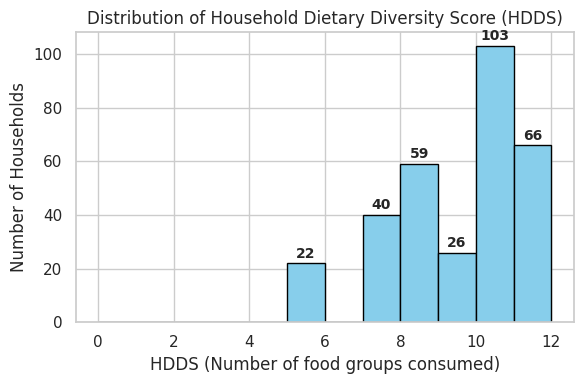

In [ ]:
#Plot:"Distribution of Household Dietary Diversity Score (HDDS)
plt.figure(figsize=(6,4))
counts, bins, patches = plt.hist(df["HDDS"], bins=range(0, 13), edgecolor='black', color='skyblue')
plt.title("Distribution of Household Dietary Diversity Score (HDDS)")
plt.xlabel("HDDS (Number of food groups consumed)")
plt.ylabel("Number of Households")
for count, bin_left, patch in zip(counts, bins[:-1], patches):
    if count > 0:
        plt.text(bin_left + 0.5, count + max(counts)*0.01, f'{int(count)}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


**The HDDS distribution shows that:**

**Most households have high dietary diversity**: the bars are tall for HDDS values around 8, 9, 10, and 11. In fact, 10 is a common score, indicating many households consumed 10 out of 11 food group categories in the recall period.

**Very few households have low diversity**: the minimum in our data was 5, and only a handful are in the 5–7 range. This is a positive sign, as it suggests even the least diverse diets still include about half of the food groups..

**The distribution is slightly left-skewed (peak near the high end)**: meaning generally good dietary diversity across the sample. This could be due to diversified cropping, market access, or food aid.

##Food Insecurity (HFIAS) Distribution

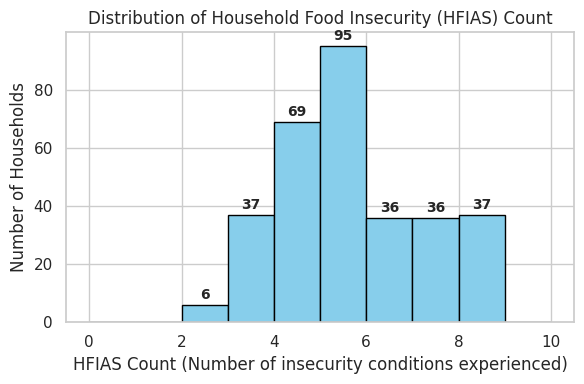

In [ ]:
# Plot: Histogram for HFIAS_count
plt.figure(figsize=(6,4))
counts, bins, patches = plt.hist(df["HFIAS_count"], bins=range(0, 11), edgecolor='black', color='skyblue')
plt.title("Distribution of Household Food Insecurity (HFIAS) Count")
plt.xlabel("HFIAS Count (Number of insecurity conditions experienced)")
plt.ylabel("Number of Households")
for count, bin_left, patch in zip(counts, bins[:-1], patches):
    if count > 0:
        plt.text(bin_left + 0.5, count + max(counts)*0.01, f'{int(count)}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


**From the HFIAS_count distribution:**

The majority of households report a low to moderate number of insecurity conditions. The most common counts are around 3-6. This suggests that while food insecurity is present (recall no household had 0), it's often limited to a few conditions for many households.

Some households do experience relatively high insecurity (up to 6 or 7 conditions). The counts drop off toward the maximum of 9, indicating very few households face extreme food insecurity across all indicators.

The distribution is roughly right-skewed: more households on the lower end (1–5 conditions) and progressively fewer with high counts. This is somewhat encouraging, but the fact that every household has at least one sign of food insecurity is concerning.

##Comparing High vs. Low CSA Adopters

<ipython-input-43-dce29cfa25bb>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<ipython-input-43-dce29cfa25bb>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



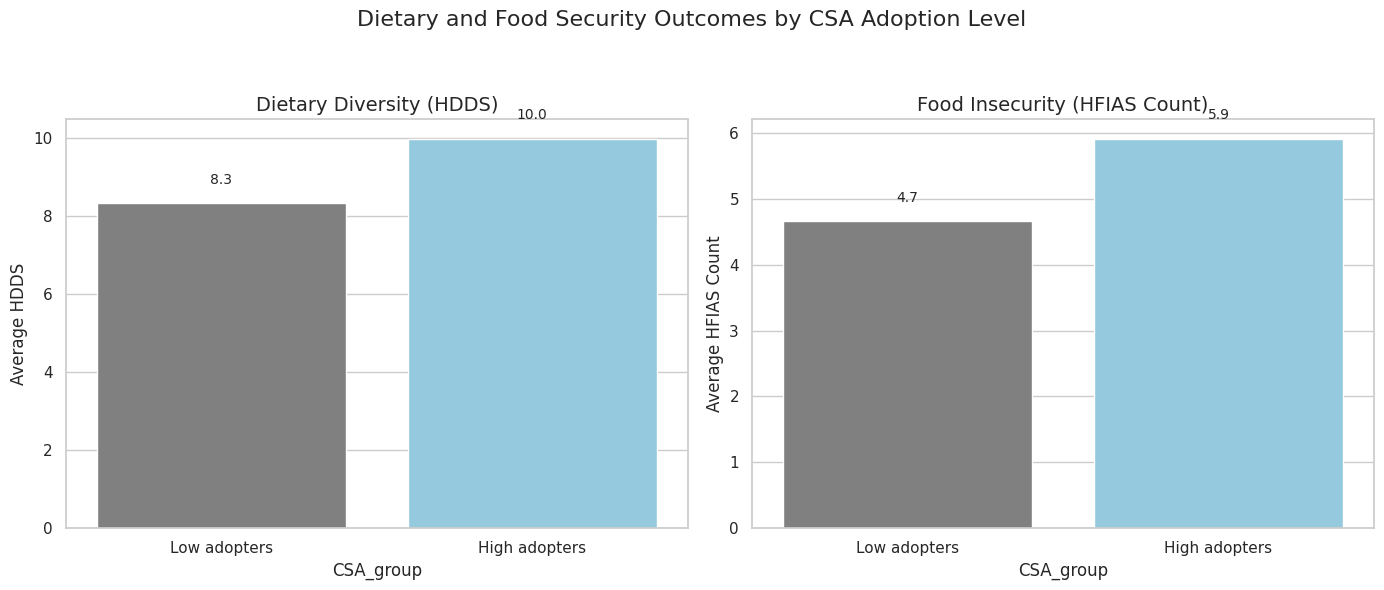

In [ ]:
# High vs Low adopters
df["CSA_group"] = np.where(df["CSA_adopt_count"] > 7, "High adopters", "Low adopters")
group_means = df.groupby("CSA_group")[["HDDS", "HFIAS_count"]].mean().reindex(["Low adopters", "High adopters"])


sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Dietary and Food Security Outcomes by CSA Adoption Level", fontsize=16)

# Plot 1: HDDS
sns.barplot(ax=axes[0], x=group_means.index, y=group_means["HDDS"], palette=["gray", "skyblue"])
axes[0].set_title("Dietary Diversity (HDDS)", fontsize=14)
axes[0].set_ylabel("Average HDDS")

for i, v in enumerate(group_means["HDDS"]):
    axes[0].text(i, v + 0.05 * max(group_means["HDDS"]), f"{v:.1f}", ha='center', fontsize=10)

# Plot 2: HFIAS Count
sns.barplot(ax=axes[1], x=group_means.index, y=group_means["HFIAS_count"], palette=["gray", "skyblue"])
axes[1].set_title("Food Insecurity (HFIAS Count)", fontsize=14)
axes[1].set_ylabel("Average HFIAS Count")

for i, v in enumerate(group_means["HFIAS_count"]):
    axes[1].text(i, v + 0.05 * max(group_means["HFIAS_count"]), f"{v:.1f}", ha='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


**HDDS**: High adopters have a higher average HDDS (~ 10.0) than low adopters (~ 8.33). This suggests households implementing more CSA practices tend to have more diverse diets. The difference (about +1.6 food groups) is quite notable, indicating a positive association between CSA adoption and diet quality.


**HFIAS_count**: Somewhat surprisingly, high adopters report a slightly higher average HFIAS_count (~ 5.9) than low adopters (~ 4.7). In other words, those with many CSA practices still experience more food insecurity conditions on average. This is counter-intuitive if we expect CSA to alleviate food insecurity. It might be that households facing more insecurity are driven to adopt more CSA practices (as coping strategies), or there could be other confounding factors (e.g., high adopters might be in more climate-vulnerable areas, hence the need for CSA).



<ipython-input-51-ec46dbe7281c>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



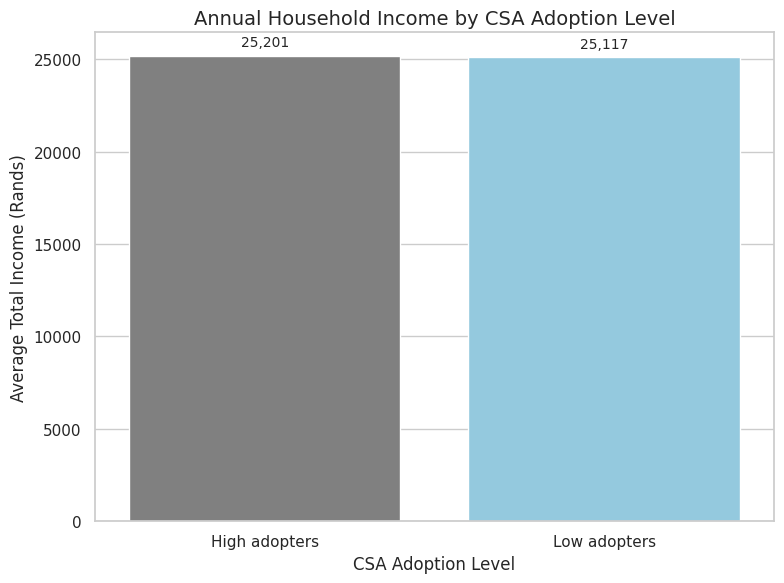

In [ ]:
#Plot: Annual Household Income by CSA Adoption Level
if "Total_income" not in group_means.columns:
    group_means = df.groupby("CSA_group")[["HDDS", "HFIAS_count", "Total_income", "farm_output"]].mean()

sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x=group_means.index, y=group_means["Total_income"], palette=["gray", "skyblue"])

plt.title("Annual Household Income by CSA Adoption Level", fontsize=14)
plt.xlabel("CSA Adoption Level")
plt.ylabel("Average Total Income (Rands)")

for i, v in enumerate(group_means["Total_income"]):
    barplot.text(i, v + 0.02 * max(group_means["Total_income"]), f"{v:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Total_income:** The average total income is roughly equal between the two groups (around 25,200 for high adopters vs 25,116 for low adopters in the sample). There is virtually no difference here. This suggests that, on average, adopting more CSA practices has not (at least yet) translated into higher household income. It's possible that any gains from CSA (e.g., cost savings, yield increases) are either modest or offset by other factors (like the cost of implementation or smaller farm sizes among adopters).


<ipython-input-52-386f9602b75a>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



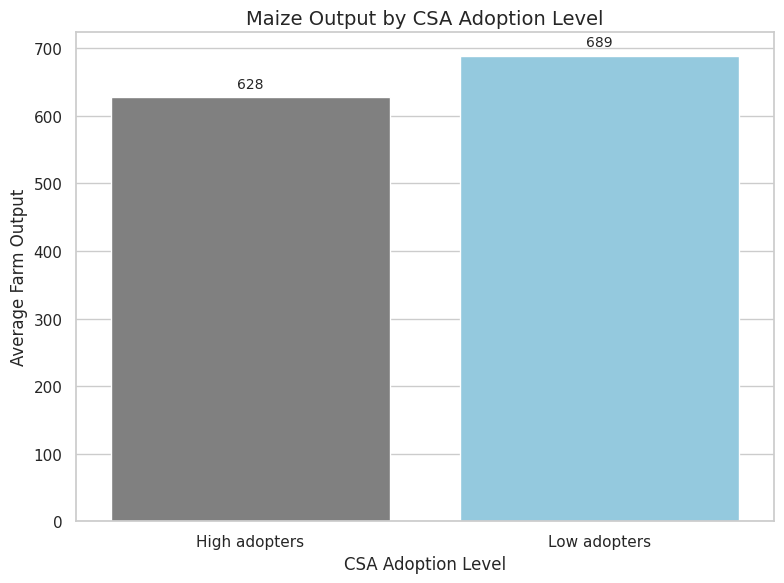

In [ ]:
# Plot: Farm_Output
if "farm_output" not in group_means.columns:
    group_means = df.groupby("CSA_group")[["HDDS", "HFIAS_count", "Total_income", "farm_output"]].mean()
sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
barplot = sns.barplot(x=group_means.index, y=group_means["farm_output"], palette=["gray", "skyblue"])

plt.title("Maize Output by CSA Adoption Level", fontsize=14)
plt.xlabel("CSA Adoption Level")
plt.ylabel("Average Farm Output")

for i, v in enumerate(group_means["farm_output"]):
    barplot.text(i, v + 0.02 * max(group_means["farm_output"]), f"{v:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Farm_Output (Maize output):** Interestingly, high adopters have slightly lower average maize output than low adopters in this data. Low adopters produced about 689 units vs 628 for high adopters. This could be related to farm size or resource constraints — perhaps smaller farmers adopt CSA intensively to boost resilience, whereas larger farmers (with higher output) might rely on conventional methods. Alternatively, it might indicate that CSA practices in this context prioritize stability and nutrition over sheer yield.


 Relationship Between CSA Adoption and Food Security Outcomes

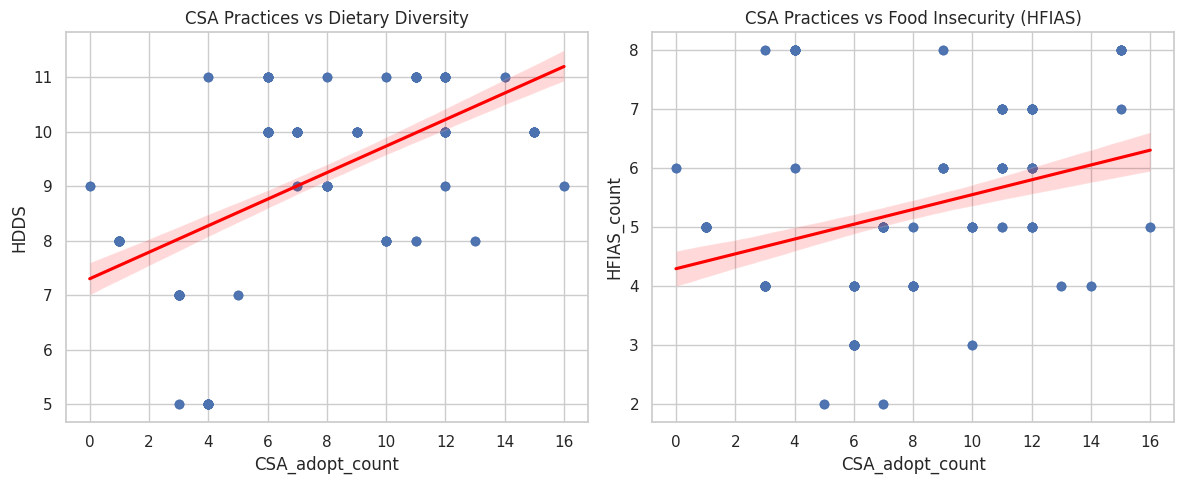

In [ ]:
#Plot: CSA Practices vs Dietary Diversity and CSA Practices vs Food Insecurity
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.regplot(x="CSA_adopt_count", y="HDDS", data=df, ax=ax[0], scatter_kws={"alpha":0.7}, line_kws={"color":"red"})
ax[0].set_title("CSA Practices vs Dietary Diversity")
ax[0].set_xlabel("CSA_adopt_count")
ax[0].set_ylabel("HDDS")
sns.regplot(x="CSA_adopt_count", y="HFIAS_count", data=df, ax=ax[1], scatter_kws={"alpha":0.7}, line_kws={"color":"red"})
ax[1].set_title("CSA Practices vs Food Insecurity (HFIAS)")
ax[1].set_xlabel("CSA_adopt_count")
ax[1].set_ylabel("HFIAS_count")
plt.tight_layout()
plt.show()


**CSA vs HDDS (left plot):** There is a clear upward trend. Households with higher CSA_adopt_count tend to have higher HDDS. The points show a positive correlation: for example, those who adopted very few practices often have HDDS in the 5–8 range, whereas those adopting 15+ practices mostly have HDDS around 10–11. The red line’s upward slope confirms this positive association.


**CSA vs HFIAS (right plot)**: Here the trend is much weaker. The red regression line is almost flat or slightly upward sloping. The scatter is more dispersed, indicating a lot of variability. There may be a slight positive correlation (as the bar chart and earlier stats suggested), meaning more CSA practices associate with a small increase in HFIAS_count. However, the relationship is not very tight — CSA adoption explains little of the variation in HFIAS. Many points with low CSA have both low and high HFIAS, and similarly for high CSA, indicating other factors at play.

##Clustering analysis

Applying K-Means Clustering (K=3)

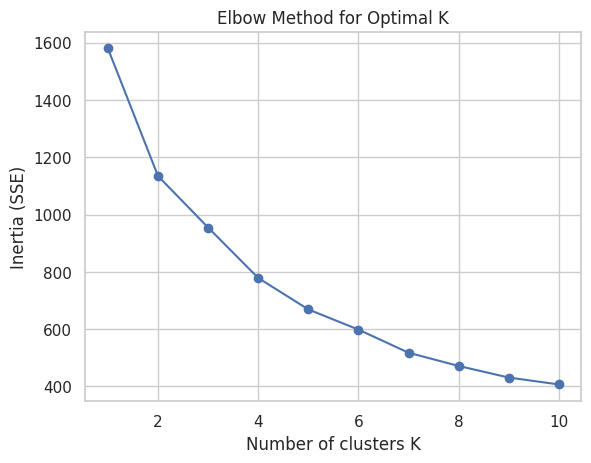

In [ ]:
#X_scaled creation
features = ["CSA_adopt_count", "HDDS", "HFIAS_count", "farm_output", "Total_income"]
X = df[features].dropna().values
X_scaled = StandardScaler().fit_transform(X)

# Elbow method:
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the inertia vs K to find the elbow
plt.figure()
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for Optimal K')
plt.show()

Silhouette Score for k=2: 0.2884
Silhouette Score for k=3: 0.2711
Silhouette Score for k=4: 0.2765
Silhouette Score for k=5: 0.2729
Silhouette Score for k=6: 0.2847
Silhouette Score for k=7: 0.2788
Silhouette Score for k=8: 0.2806
Silhouette Score for k=9: 0.2800
Silhouette Score for k=10: 0.2931


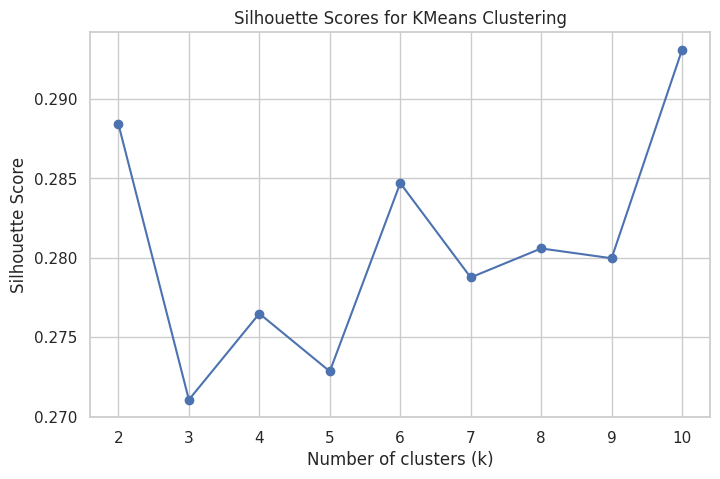

In [ ]:
#Plot: Silhoutte scores
features = ["CSA_adopt_count", "HDDS", "HFIAS_count", "farm_output", "Total_income"]
X = df[features].dropna()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate silhouette scores for a range of cluster values
silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores[k] = score
    print(f"Silhouette Score for k={k}: {score:.4f}")




plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.title("Silhouette Scores for KMeans Clustering")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

**Use of k-value**

While the Silhouette Score suggests that K=10(~ 0.29) has the highest cluster separation. We chose to use K=3 for the following reasons:
Practical usefulness and comprehensive analysis: K=3 gives us the opportunity to analyze the data and gain useful and insightful conclusions by avoiding overfitting. The elbow method suggests that is the optimal number is K=3.

In [ ]:
# Fit KMeans with 3 clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, n_init=20, random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_  # Cluster labels for each household

# Size of each cluster

unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} households")


Cluster 0: 86 households
Cluster 1: 208 households
Cluster 2: 22 households


In [ ]:
## Calculate cluster centroids in original scale
centroids = StandardScaler().fit(X).inverse_transform(kmeans.cluster_centers_)
cent_df = pd.DataFrame(centroids, columns=features)
cent_df.index = [f"Cluster_{i}" for i in range(optimal_k)]
print(cent_df.round(2))


           CSA_adopt_count   HDDS  HFIAS_count  farm_output  Total_income
Cluster_0             1.60   7.58         2.52       725.31      23910.72
Cluster_1             9.44  10.05         2.87       642.43      25705.95
Cluster_2             3.00   5.00         7.00       618.86      24768.05


Cluster_0- Low adoption, high output: Houses with very low CSA adoption(≈2 practices). They have the highest farm output(~ 725) with a moderate to high dietary diversity(HDDS~ 8) and incomes are comparatively low.

Cluster_1- High Adoption, Moderate ouput: Houses with high CSA adoption and moderate output have the highest dietary diversity(HDDS~ 10) and moderate food insecurity(HFIAS~ 3). Maize output ( ~642) is not as high as the low adoptors output but have greater total income.

Cluster_2: Moderate Adoption, Low Output: Farmers who have adopted only a few CSA practices(meaan~ 3) and face the poorest nutrition and security outcomes. They have the lowest diatery diversity(HDDS ~ 5.0) and the highest food insecurity(HFIAS~ 7.00). Their total income is surprisingly higher then the  cluster_0.


**Visualizing Clusters PCA**

Variance explained by PC1 and PC2: [0.3464389  0.23620928]


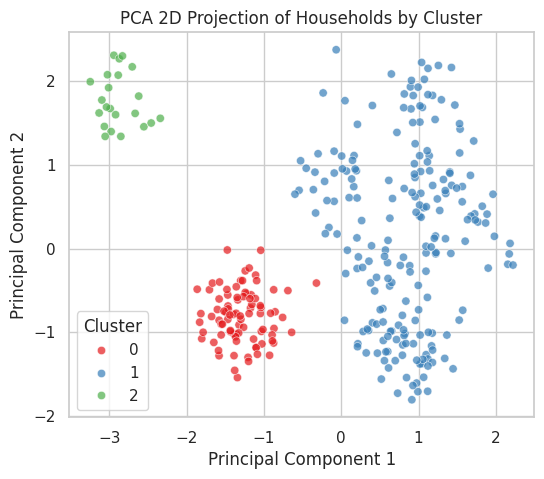

In [ ]:
#Plot: PCA 2D Projection of Households by Cluster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_)

# Plot: PCA scatte
plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="Set1", alpha=0.7)
plt.title("PCA 2D Projection of Households by Cluster")
plt.ylabel("CSA Adoption")
plt.legend(title="Cluster")
plt.show()


Principal Component 1:

Cluster 1(High CSA adopters) had a slight increase in farm output and a notabily higher then Cluster 0(Low CSA adopters), suggesting that CSA boots both productivity and HDDS. The difference between the  HFIAS of the two clusters is minor with ~ 3 for Cluster 0 and ~ 7 for cluster 1.

<ipython-input-82-dea9d55b3ea7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



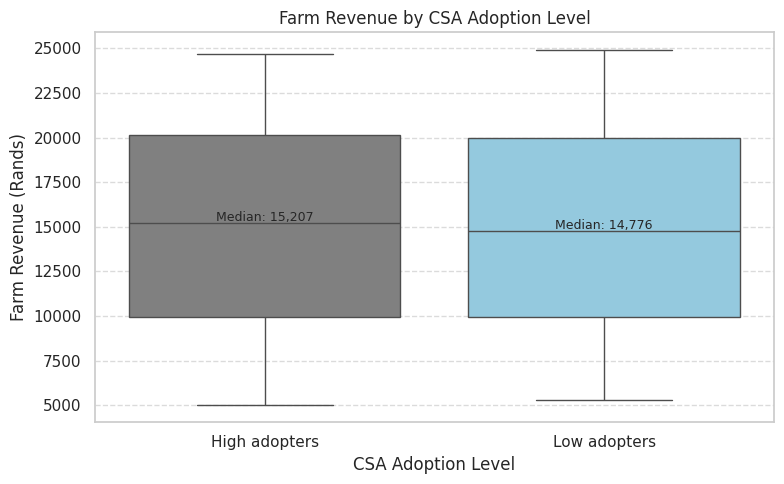

In [ ]:
# Boxplot of Farm Revenue by CSA Adoption Level
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["CSA_group"], y=df["farm_revenue"], palette=["gray", "skyblue"])
plt.title("Farm Revenue by CSA Adoption Level")
plt.xlabel("CSA Adoption Level")
plt.ylabel("Farm Revenue (Rands)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for group in df["CSA_group"].unique():
    median_val = df[df["CSA_group"] == group]["farm_revenue"].median()
    plt.text(x=group, y=median_val + 100, s=f"Median: {median_val:,.0f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

##Linear Regression Analysis

In [ ]:
import statsmodels.api as sm

# Prepare data for regression
X = sm.add_constant(df["CSA_adopt_count"])

# Model 1: HDDS as outcome
y_hdds = df["HDDS"]
model_hdds = sm.OLS(y_hdds, X).fit()

# Model 2: HFIAS_count as outcome
y_hfias = df["HFIAS_count"]
model_hfias = sm.OLS(y_hfias, X).fit()

# Output the regression summaries (coefficients and p-values)
print("Regression Results: HDDS ~ CSA_adopt_count")
print(model_hdds.summary().tables[1])  # coefficients table

print("\nRegression Results: HFIAS_count ~ CSA_adopt_count")
print(model_hfias.summary().tables[1])


Regression Results: HDDS ~ CSA_adopt_count
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3041      0.152     47.915      0.000       7.004       7.604
CSA_adopt_count     0.2435      0.019     13.147      0.000       0.207       0.280

Regression Results: HFIAS_count ~ CSA_adopt_count
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.2962      0.162     26.486      0.000       3.977       4.615
CSA_adopt_count     0.1255      0.020      6.369      0.000       0.087       0.164


HDDS ~ CSA_adopt_count:

Intercept ≈ 7.30 (this would be the expected HDDS when CSA_count = 0).

CSA_adopt_count coefficient ≈ +0.2435. This means each additional CSA practice is associated with an increase of about 0.24 in the HDDS, on average.

The p-value for the CSA coefficient is extremely low (on the order of 10^-38, essentially p < 0.001), indicating this positive effect is statistically significant.

The R-squared of this model (not fully shown above, but can be inferred from the correlation) is around 0.12 (since correlation^2 ~ 0.60^2 = 0.36). So about 36% of the variance in HDDS is explained by CSA adoption count alone, which is quite significant for a single-factor model.


HFIAS_count ~ CSA_adopt_count:


Intercept ≈ 4.29 (expected HFIAS_count when CSA_count = 0).

CSA_adopt_count coefficient ≈ +0.1255. This suggests each additional CSA practice is associated with a 0.1255 increase in the HFIAS_count, on average.


The R-squared here is very low (since correlation^2 ~ 0.34^2 = 0.12), meaning CSA adoption explains only ~12% of the variance in HFIAS_count. In other words, while the positive coefficient is statistically reliable (likely due to the decent sample size of 316), it is a small effect and many other factors may influence food insecurity.

##Interpretation:


There is a strong positive relationship between CSA adoption and dietary diversity. This might imply that CSA practices (such as crop diversification, kitchen gardens, improved agronomy, etc.) are effectively improving the variety of foods that households produce or access.



The K-Means clustering reveals groups of farmers with coherent profiles.

There is a weak positive relationship between CSA adoption and food insecurity count, meaning households with more CSA practices report slightly more food insecurity issues.
One cluster (High adopter) show moderate output, high income and the high HDDS and a relatively low HFIAS;  another cluster (low adopter) show high output and high HDDS , which disproves our hypothesis. This counter-intuitive result may indicate that adoption alone is not sufficient to eliminate food insecurity and that the most vulnerable households (with more insecurity) are perhaps adopting CSA as a coping mechanism. It's also possible that some CSA practices take time to bear fruit, or that high adopters have faced severe climate stresses that prompted adoption yet still struggle with food access.

##**Recommendations**##

• Prioritize the Fit of CSA Practices, Not Just the Count - Adopting many
CSA practices don’t guarantee improved productivity.

• Use HDDS and HFIAS in Targeting and Monitoring CSA Programs -
Routine collection of HDDS and HFIAS scores should be used to
monitor CSA outcomes, not just yields or incomes. This makes CSA
interventions more nutrition-sensitive and people-centered.

• Direct More Support to Vulnerable Farmers Adopting CSA Out of
Necessity - Households that are food insecure but still adopt CSA need
targeted support like input subsidies, social protection, and food
vouchers to prevent further marginalization. These farmers are
proactive but constrained.

• CSA Must Be Coupled with Food Access and Resilience Strategies - The
weak correlation between CSA and reduced food insecurity (HFIAS)
implies that food access, stability, and utilization must be addressed
alongside production. CSA programs should therefore integrate
seasonal food storage solutions and household food budgeting
support.  

• Recognize CSA as a Means to an End, Not the End Itself - CSA should be
integrated into broader rural development goals such as clean water,
land rights, and off-farm income support so that its benefits don’t end in
the field but carry into the household and community.

In [ ]:
from decimal import Decimal
input = input("Enter either investment or bond from the menu above to proceed)
def get_option(input.lower):
    match options:
        case "investement":
            amount= Decimal(input("enter the investment amount"))
            percentage= int(input("Enter percentage"))
            return amount*percentage/100
        case "bond":
            return

In [ ]:
from decimal import Decimal

def get_option(user_choice):
    match user_choice.lower():
        case "investment":
            amount = Decimal(input("Enter the investment amount: "))
            percentage = Decimal(input("Enter the interest rate (%): "))

            return f"Total return on investment: {total:.2f}"

        case "bond":

        case _:
            return "Invalid option. Please enter 'investment' or 'bond'."

# Main code execution
user_input = input("Enter either 'investment' or 'bond' from the menu above to proceed: ")
result = get_option(user_input)
print(result)


In [ ]:
from decimal import Decimal
import math

def get_option(user_choice):
    match user_choice.lower():
        case "investment":
            amount = Decimal(input("Enter the investment amount: "))
            percentage = Decimal(input("Enter the interest rate (%): "))
            years = Decimal(input("Enter number of years: "))
            interest_type = input("Simple or compound interest? ").lower()

            if interest_type == "simple":
                total = amount*(1 + percentage * years)
            elif interest_type == "compound":
                total = amount * math.pow((1 + percentage), years)
            else:
                return "Invalid interest type."
            return f"Total return on investment: {total:.2f}"

        case "bond":
            house_value = Decimal(input("Enter the present value of the house: "))
            interest_rate = Decimal(input("Enter the annual interest rate (%): "))
            months = int(input("Enter the number of months for repayment: "))

            monthly_interest = (interest_rate / 100) / 12
            repayment = (monthly_interest * house_value) / (1 - (1 + monthly_interest) ** (-months))
            return f"Monthly repayment: {repayment:.2f}"

        case _:
            return "Invalid option. Please enter 'investment' or 'bond'."

# Main code execution
user_input = input("Enter either 'investment' or 'bond' from the menu above to proceed: ")
result = get_option(user_input)
print(result)
